### Sequence Graph Demostration for Navigation

In [1]:
from data_loader import *
import time
import ipywidgets as widgets
from IPython.display import display, Image, clear_output
from shapely.geometry import Point, Polygon

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


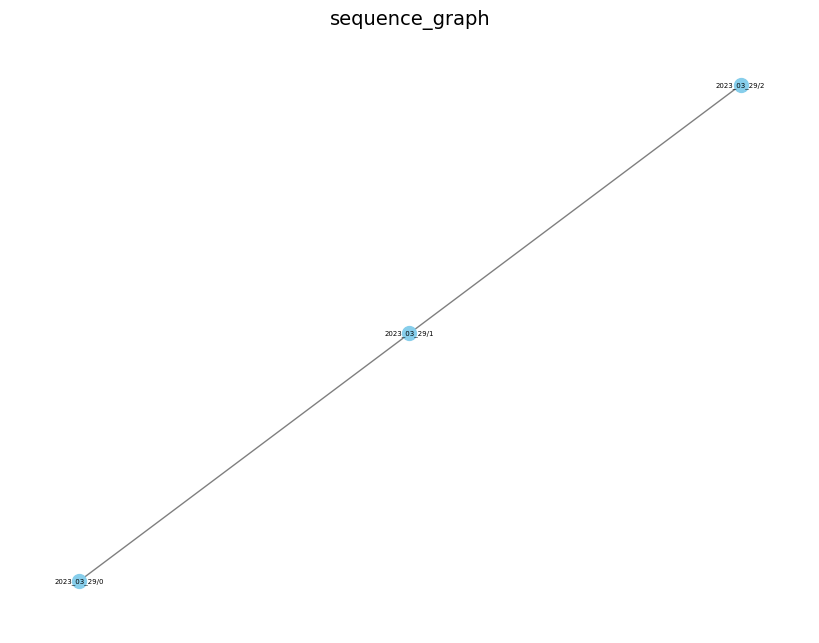

In [2]:
sequence_graph = load_sequence_graph('/lab/kiran/navisim-1/assets/sequence_graph.gpickle')
plot_seq_graph(sequence_graph, out_path='/lab/kiran/navisim-1/assets')

In [3]:
sectors = get_sequence(sequence_graph)
# sectors

In [4]:
seq_id = list(sectors.keys())[0]
# Set up your widgets
text_box = widgets.Text(
    placeholder='Enter direction : (W,A,S,D)',
    description='Direction:',
    continuous_update=False
)
output = widgets.Output()
sector_id = 0
global_pos = None
elevation_map = global_pos
occupancy_map = None

def check_coordinate(boundary, coo):
    x, y = coo
    minx, miny, maxx, maxy = polygon.bounds
    if boundary.covers(Point(x, y)):
        return 0
    
    centroid = polygon.centroid
    cx, cy = centroid.x, centroid.y
    if x < cx:
        return -1
    elif x > cx:
        return 1

    return 

def get_x_at_y(polygon, y0, epsilon=1e-8):
    x_coords = []
    coords = list(polygon.exterior.coords)

    for i in range(len(coords) - 1):
        (x1, y1), (x2, y2) = coords[i], coords[i + 1]

        # Exact horizontal match
        if abs(y1 - y2) < epsilon and abs(y1 - y0) < epsilon:
            x_coords.extend([x1, x2])
            continue

        # Interpolate only when crossing y0
        if (y1 - y0) * (y2 - y0) < 0:
            t = (y0 - y1) / (y2 - y1)
            x = x1 + t * (x2 - x1)
            pt = Point(x, y0)
            if polygon.boundary.contains(pt) or polygon.boundary.touches(pt):
                x_coords.append(x)

        # Endpoints exactly on y0
        elif abs(y1 - y0) < epsilon:
            pt = Point(x1, y1)
            if polygon.boundary.touches(pt):
                x_coords.append(x1)
        elif abs(y2 - y0) < epsilon:
            pt = Point(x2, y2)
            if polygon.boundary.touches(pt):
                x_coords.append(x2)

    if not x_coords:
        # Fallback: return full x extent of polygon
        xs = [pt[0] for pt in polygon.exterior.coords]
        return [min(xs), max(xs)]

    print(sorted(set(x_coords)))
    return sorted(set(x_coords))

def update_coordinate(direction, coordinate):
    x, y = coordinate

    # move left
    if direction == 'A':
        return (x - 4, y)
    # move right
    elif direction == 'D':
        return (x + 4, y)
    
    # move up
    elif direction == 'W':
        return (x, y + 4)
    
    # move down
    elif direction == 'S':
        return (x, y - 4)
    return (x, y)

def benchmark(g, width = 1280, height = 720):
    vis = o3d.visualization.Visualizer()
    vis.create_window(width=width, height=height)
    vis.clear_geometries()
    vis.add_geometry(g)
    vis.poll_events()
    vis.update_renderer()


def handle_submit(change):
    global sector_id, global_pos, elevation_map, occupancy_map, polygon

    try:
        direction = change["new"]
        with output:
            if not direction:
                return

            clear_output(wait=True)

            # pcd = get_gaussian_splat(seq_id, str(sector_id))
            # start = time.time()
            # benchmark(pcd)
            # end = time.time()

            # frame_time = end - start
            # fps = 1 / frame_time
            
            # print(f"Frame time: {frame_time:.4f}s, FPS: {fps:.2f}")

            # Step 1: Update coordinate based on direction
            if global_pos is None:
                # Initialize in center
            
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                polygon = get_polygon(seq_id, str(sector_id))
                global_pos = (elevation_map.shape[1] // 2, elevation_map.shape[0] // 2)
            else:
                global_pos = update_coordinate(direction, global_pos)

                # Step 2: Fetch current sector polygon and check position
                polygon = get_polygon(seq_id, str(sector_id))
                check = check_coordinate(polygon, global_pos)
                print("check", check)

                if check != 0:
                    # Step 3: update sector
                    sector_id = max(0, sector_id + check)

                    # Step 4: fetch new maps from new sector
                    elevation_map = get_elevation_map(seq_id, str(sector_id))
                    occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                    polygon = get_polygon(seq_id, str(sector_id))

                    # Step 5: adjust coordinate to be just inside new polygon
                    x_candidates = get_x_at_y(polygon, global_pos[1])
                    print("x_candidates", x_candidates)

                    if x_candidates:
                        if check == 1:  # moving left to right
                            global_pos = (int(x_candidates[0]) + 1, global_pos[1])
                        elif check == -1:  # moving right to left
                            global_pos = (int(x_candidates[-1]) - 1, global_pos[1])

                else:
                    # Still in bounds → update map normally
                    elevation_map = get_elevation_map(seq_id, str(sector_id))
                    occupancy_map = get_occupancy_map(seq_id, str(sector_id))

            # Step 6: Plot everything using latest map and position
            plot_maps(elevation_map, occupancy_map, polygon, global_pos)

    except Exception as e:
        with output:
            clear_output(wait=True)
            print(f"Error: {e}")
    finally:
        text_box.value = ""


text_box.observe(handle_submit, names='value')

In [5]:
display(text_box, output)

Text(value='', continuous_update=False, description='Direction:', placeholder='Enter direction : (W,A,S,D)')

Output()

In [6]:
import random
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
from shapely.geometry import Point
import open3d as o3d

# INITIAL SETUP
seq_id = list(sectors.keys())[0]
sector_id = 0
global_pos = None
elevation_map = global_pos
occupancy_map = None
polygon = None

output = widgets.Output()
display(output)

def check_coordinate(boundary, coo):
    x, y = coo
    minx, miny, maxx, maxy = polygon.bounds

    centroid = polygon.centroid
    cx, cy = centroid.x, centroid.y
    if x < cx:
        return boundary.covers(Point(x, y)), -1
    return boundary.covers(Point(x, y)), 1



import numpy as np
from shapely.geometry import Point

def find_nearest_accessible(polygon, occupancy_map):
    center = polygon.centroid
    x, y = int(center.x), int(center.y)
    
    if 0 <= x < occupancy_map.shape[1] and 0 <= y < occupancy_map.shape[0]:
        if occupancy_map[y, x] == 0:
            return (x, y)
    
    # Search nearby if center is not accessible
    for r in range(1, 10):  # Search radius
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                nx, ny = x + dx, y + dy
                if (0 <= nx < occupancy_map.shape[1] and 0 <= ny < occupancy_map.shape[0]
                        and occupancy_map[ny, nx] == 0):
                    return (nx, ny)
    
    return (x, y)  # fallback if no accessible point found


def update_coordinate(direction, occupancy_map, coordinate, movement=2):
    x, y = coordinate

    moves = {
        'A': (-movement, 0),  # left
        'D': (movement, 0),   # right
        'W': (0, movement),   # up
        'S': (0, -movement),  # down
    }

    # Intended movement
    dx, dy = moves.get(direction, (0, 0))
    new_x, new_y = x + dx, y + dy

    # Check bounds
    if not (0 <= new_x < occupancy_map.shape[1] and 0 <= new_y < occupancy_map.shape[0]):
        print('out side the bounds')
        return (new_x, new_y)

    # Try normal movement first
    if occupancy_map[new_y, new_x] == 0:
        return (new_x, new_y)

    # Wall-following behavior: slide left/right or up/down
    # Prefer slight perpendicular movements to stick to the wall
    if direction in ['W', 'S']:  # moving vertically
        candidates = [
            (x - movement, y),  # left
            (x + movement, y),  # right
        ]
    elif direction in ['A', 'D']:  # moving horizontally
        candidates = [
            (x, y + movement),  # up
            (x, y - movement),  # down
        ]
    else:
        candidates = []

    # Try the candidates
    for nx, ny in candidates:
        if 0 <= nx < occupancy_map.shape[0] and 0 <= ny < occupancy_map.shape[1]:
            if occupancy_map[ny, nx] == 0:
                return (nx, ny)

    # If no wall-following move possible, stay
    return (x, y)

def benchmark(g, width=1280, height=720):
    vis = o3d.visualization.Visualizer()
    vis.create_window(width=width, height=height)
    vis.clear_geometries()
    vis.add_geometry(g)
    vis.poll_events()
    vis.update_renderer()

def move_agent(direction):
    global sector_id, global_pos, elevation_map, occupancy_map, polygon

    with output:
        clear_output(wait=True)

        if not direction:
            return

        start = time.time()

        if global_pos is None:
            # First time initialization
            elevation_map = get_elevation_map(seq_id, str(sector_id))
            occupancy_map = get_occupancy_map(seq_id, str(sector_id))
            polygon = get_polygon(seq_id, str(sector_id))
            center = polygon.centroid
            global_pos = find_nearest_accessible(polygon, occupancy_map)

        else:
            # Try moving based on input direction
            global_pos = update_coordinate(direction, occupancy_map, global_pos)

            # Update polygon
            polygon = get_polygon(seq_id, str(sector_id))
            is_agent_within_boundary, move_direction = check_coordinate(polygon, global_pos)

            if is_agent_within_boundary:
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
            else:
                # Crossed sector boundary
                sector_id = max(0, sector_id + move_direction)
                elevation_map = get_elevation_map(seq_id, str(sector_id))
                occupancy_map = get_occupancy_map(seq_id, str(sector_id))
                polygon = get_polygon(seq_id, str(sector_id))

                global_pos = find_nearest_accessible(polygon, occupancy_map)

        end = time.time()
        fps = 1 / (end - start)
        print(f"Direction: {direction} | Position: {global_pos} | FPS: {fps:.2f}")
        plot_maps(elevation_map, occupancy_map, polygon, global_pos)


Output()

In [7]:
import random
import time

directions = ['W', 'A', 'S', 'D']


def random_walk(steps=100, delay=0.5):
    for _ in range(steps):
        dir = random.choice(directions)
        # print(f"Moving {dir}")
        move_agent(dir)
        time.sleep(delay)

In [ ]:
random_walk(steps=200, delay=0.5)  # moves randomly 50 times with 0.3 sec delay